In [31]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

# --- Global styling and constants ---
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18

# Define shared plot colors and legend ordering
COLOR_MAP = {
    '0': '#1f77b4',  # blue
    '1': '#d78e20',  # orange-ish
    '2': '#c459a1',  # magenta
    '3': '#498c41',  # green
}
LEGEND_ORDER = ['QPA 0', 'Theory', 'QPA 1', 'QPA 2', 'QPA 3']

## Panel 5 — Rydberg

Placeholder for Rydberg system plots. TODO:
- Load Rydberg dataset(s)
- Process and normalize as needed
- Plot observables with error bars

Average base fidelity: 0.8201289239384646
0.8201289239384646


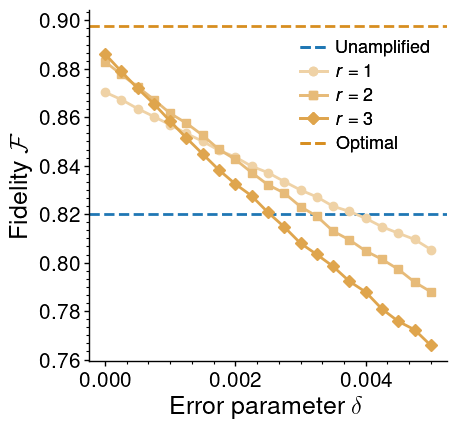

Plot saved to: aer_ryd_estimation/plotting_results/fidelity_125_k4_nshots102400_eps0.0-0.001_s41.svg


In [81]:
import os
import csv
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- Enhanced style and axes settings ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH = 72
FIGSIZE = (345 / PT_PER_INCH, 325 / PT_PER_INCH)

font_scale = 1.5
label_fs = int(12 * font_scale)
legend_fs = int(9 * font_scale)
tick_labelsize = int(10 * font_scale)
scaled_markersize = int(4 * font_scale)  # Consistent with example

# === CONFIGURATION ========================================================
nshots      = 102400
k           = 4
eps_steps   = 41
eps_min     = 0.0
eps_max     = 0.001
eigenstates = 5

base_folder = (
    f"aer_ryd_estimation/simulation_outputs/"
    f"ryd_estimation_{eigenstates**3}_eigenstates_k{k}_shots{nshots}"
    f"_eps{eps_min}-{eps_max}_s{eps_steps}"
)
outfile_svg = (
    f"aer_ryd_estimation/plotting_results/"
    f"fidelity_{eigenstates**3}_k{k}_nshots{nshots}_eps{eps_min}-{eps_max}_s{eps_steps}.svg"
)

datafile           = "aer_ryd_estimation/all_states_5_eigenstates.npz"
exact_state_file   = "aer_ryd_estimation/exact_state.npz"
# ===========================================================================

# === LOAD PROBABILITIES AND STATES =======================================
data         = np.load(datafile, allow_pickle=True)
probs        = data["probs"]
input_states = data["states"]

exact_state  = np.load(exact_state_file, allow_pickle=True)["state"]
# ===========================================================================

# === COMPUTE BASE FIDELITY ===============================================
avg_base_fidelity = 0.0
for prob, state_tuple in zip(probs, input_states):
    q3_input_state = state_tuple[1]                       # third register state
    fid            = abs(np.vdot(q3_input_state, exact_state))**2
    avg_base_fidelity += prob * fid
print("Average base fidelity:", avg_base_fidelity)
print(avg_base_fidelity)
# ===========================================================================

# === LOAD QPA RESULTS, WEIGHT BY PROBS ====================================
fidelity_qpa = defaultdict(list)

for idx, prob in enumerate(probs):
    input_path = os.path.join(base_folder, f"index{idx}")
    if not os.path.exists(input_path):
        print("Missing:", input_path)
        continue

    for folder in os.listdir(input_path):
        if not folder.startswith("nqpa"):
            continue
        nqpa_val  = int(folder.replace("nqpa", ""))
        csv_path  = os.path.join(input_path, folder, "merged_results.csv")
        if not os.path.exists(csv_path):
            print("Missing CSV:", csv_path)
            continue

        with open(csv_path, newline="") as f:
            reader = csv.reader(f)
            header = next(reader)               # "epsilon, fidelity"
            for eps_str, fid_str in reader:
                eps = float(eps_str)
                fid = float(fid_str)
                fidelity_qpa[nqpa_val].append((eps, fid * prob))
# ===========================================================================

# === GROUP & AGGREGATE ====================================================
final_qpa = {}
for nqpa, entries in fidelity_qpa.items():
    buckets = defaultdict(list)
    for eps, w_fid in entries:
        buckets[eps].append(w_fid)
    final_qpa[nqpa] = {eps: sum(vals) for eps, vals in buckets.items()}
# === PLOTTING =============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)

# Base yellow
base_yellow = np.array(mpl.colors.to_rgb("#d78e20"))

# Dashed reference lines
ax.axhline(
    y=avg_base_fidelity,
    linestyle="--",
    color="#1f77b4",
    linewidth=2,
    label="Unamplified"
),

# Lighter variants
colors = [
    base_yellow * 0.4  + np.ones(3) * 0.6,
    base_yellow * 0.6 + np.ones(3) * 0.4,
    base_yellow * 0.8 + np.ones(3) * 0.2
    
]
markers = ['o', 's', 'D']

# Plot amplified curves (r = 1,2,3)
for idx, nqpa in enumerate(sorted(final_qpa.keys())):
    if nqpa == 0:
        continue  # skip unamplified here

    color = colors[idx % len(colors)]
    marker = markers[(nqpa-1) % len(markers)]  # r starts at 1
    eps_list   = sorted(eps for eps in final_qpa[nqpa].keys() if eps <= 0.0005)
    delta_list = [eps * 10 for eps in eps_list]  # Multiply by 10
    fidelities = [final_qpa[nqpa][eps] for eps in eps_list]

    ax.plot(
        delta_list,
        fidelities,
        markersize=scaled_markersize,
        color=color,
        marker=marker,
        linewidth=2,
        label=fr"$r={nqpa}$"
    )



ax.axhline(
    y=0.897822559792652,
    linestyle="--",
    color="#d78e20",
    linewidth=2,
    label="Optimal"
),

# Fine-tune axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)

ax.set_xlabel(r"Error parameter $\delta$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

# Legend for r (colors)
leg1 = ax.legend(
    loc="upper right",
    fontsize=legend_fs,
    frameon=False,
    title=None,
    borderaxespad=0.5,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.4,
    borderpad=0.4,
    columnspacing=1.0,
    ncol=1,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(1.0, 0.96)  # Slightly shifted down
    # 1.0 is right edge, 0.96 is just below default (1.0)
    # Adjust as needed for your plot
    # Default is (1.0, 1.0)
    # This moves the legend a little lower
    # Remove or adjust if not desired
)
ax.add_artist(leg1)

# Save and show
fig.tight_layout()
fig.savefig(outfile_svg, format='svg')
plt.show()

print("Plot saved to:", outfile_svg)

## Panel 6 — State Preparation

Comparison of IBM experiment datasets (k=2, n=5 and n=3) in the same style as the main plot.

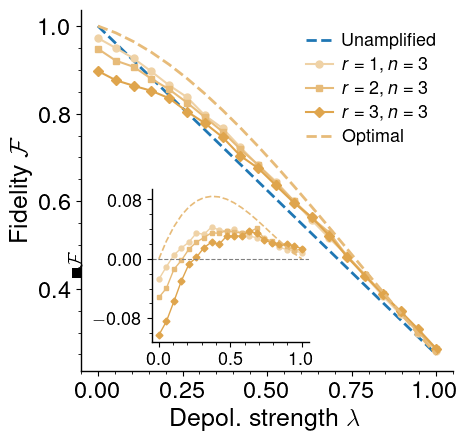

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Parameters
k = 2
shots = 1000
lambda_min = 0.0
lambda_max = 1.0
lambda_steps = 20
nrandom = 500
gatenoise = 0.0
aer = 'false'
fake = 'false'

base_yellow = np.array(mpl.colors.to_rgb("#d78e20"))
custom_colors = [
    '#1f77b4',
    tuple(base_yellow * 0.4 + np.ones(3) * 0.6),
    tuple(base_yellow * 0.6 + np.ones(3) * 0.4),
    tuple(base_yellow * 0.8 + np.ones(3) * 0.2),
]
markers = ['o', 's', 'D']
scaled_markersize = 5
optimal_color = tuple(base_yellow * 0.6 + np.ones(3) * 0.4)

font_scale = 1.5
legend_fs = int(9 * font_scale)
label_fs = int(12 * font_scale)
PT_PER_INCH = 72
FIGSIZE = (345 / PT_PER_INCH, 325 / PT_PER_INCH)

mpl.rcParams['xtick.labelsize'] = 17
mpl.rcParams['ytick.labelsize'] = 17

# Folder structure
task_type = 'three_circuits_ibm_global_sampler'
simulation_subfolder = 'simulation_outputs'
plotting_subfolder = 'plotting_results'

filesuffix = f'k{k}_shots{shots}_lambda{lambda_min}-{lambda_max}_s{lambda_steps}_r{nrandom}_g{gatenoise}_aer{aer}_fake{fake}'
plotting_folder = f'{task_type}/{plotting_subfolder}'
simulation_folder = f'{task_type}/{simulation_subfolder}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'

os.makedirs(plotting_folder, exist_ok=True)
os.makedirs(simulation_folder, exist_ok=True)

nqpa_dirs = sorted([d for d in os.listdir(results_folder) if os.path.isdir(os.path.join(results_folder, d))])

# --- Pre-load all data ---
data_by_nqpa = {}
for i, nqpa_dir in enumerate(nqpa_dirs):
    color = custom_colors[i % len(custom_colors)]
    nqpa = nqpa_dir[4]
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambda.csv")
    if not os.path.exists(combined_csv):
        print(f"Warning: No combined CSV found in {nqpa_dir}")
        continue
    df = pd.read_csv(combined_csv).sort_values("lambda")
    data_by_nqpa[nqpa] = {
        'lambda': df['lambda'].values,
        'fidelity': df[f'QPA_{nqpa}'].values,
        'color': color,
    }

base_fidelity = data_by_nqpa.get('0', {}).get('fidelity')
lambda_base = data_by_nqpa.get('0', {}).get('lambda')

# --- Main Figure ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# --- Embedded ΔF Inset ---
inset_fs = int(label_fs * 0.78)
inset_tick_fs = int(17 * 0.78)
axins = ax.inset_axes([0.19, 0.08, 0.4224, 0.4224])
axins.patch.set_alpha(0)

if base_fidelity is not None:
    for nqpa, d in sorted(data_by_nqpa.items()):
        if nqpa == '0':
            continue
        fidelity_diff = d['fidelity'] - base_fidelity
        axins.plot(d['lambda'], fidelity_diff,
                   marker=markers[(int(nqpa)-1) % len(markers)],
                   markersize=scaled_markersize * 0.7,
                   color=d['color'], linewidth=1)
    lambda_theory = lambda_base
    theory_curve = (1/8) * (-2+lambda_theory) * (1+lambda_theory) * (-4+3*lambda_theory)
    axins.plot(lambda_theory, theory_curve - base_fidelity, '--', color=optimal_color, linewidth=1.2)

axins.axhline(0, color='gray', linestyle='--', linewidth=0.8)
axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)
axins.spines["left"].set_linewidth(1)
axins.spines["bottom"].set_linewidth(1)
axins.xaxis.set_ticks_position("bottom")
axins.yaxis.set_ticks_position("left")
axins.xaxis.set_minor_locator(AutoMinorLocator())
axins.yaxis.set_minor_locator(AutoMinorLocator())
axins.tick_params(labelsize=inset_tick_fs, which='both', direction='out')
axins.set_yticks([-0.08, 0, 0.08])
axins.set_xticks([0, 0.5, 1])
axins.set_ylabel(r"$\Delta\mathcal{F}$", fontsize=inset_fs)

# --- Absolute Fidelity (main axes) ---
for nqpa, d in sorted(data_by_nqpa.items()):
    if nqpa == '0':
        ax.plot(d['lambda'], d['fidelity'], linestyle='--', linewidth=2,
                color=d['color'], label="Unamplified")
    else:
        ax.plot(d['lambda'], d['fidelity'],
                marker=markers[(int(nqpa)-1) % len(markers)],
                markersize=scaled_markersize, color=d['color'], label=fr"$r={nqpa}, n=3$")

lambda_theory_main = np.linspace(lambda_min, lambda_max, lambda_steps)
theory_main = (1/8) * (-2+lambda_theory_main) * (1+lambda_theory_main) * (-4+3*lambda_theory_main)
ax.plot(lambda_theory_main, theory_main, '--', color=optimal_color, linewidth=2, label='Optimal')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel(r"Depol. strength $\lambda$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)
ax.legend(
    loc="upper right", fontsize=legend_fs, frameon=False,
    borderaxespad=0.5, handlelength=1.5, handletextpad=0.5,
    labelspacing=0.4, borderpad=0.4, columnspacing=1.0,
    ncol=1, fancybox=False, edgecolor="black", bbox_to_anchor=(1.0, 0.98),
)

fig.tight_layout()
abs_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_absolute_fidelity.svg'
fig.savefig(abs_plot_path, format='svg')
plt.show()

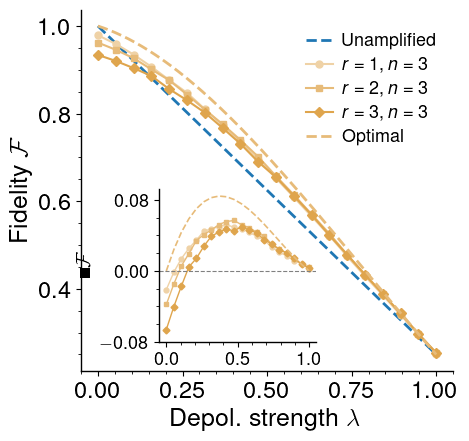

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- Configuration ---
k = 2
shots = 10000
lambda_min = 0.0
lambda_max = 1.0
lambda_steps = 20
nrandom = 5000
gatenoise = 0.0
aer = 'false'
fake = 'true'

base_yellow = np.array(mpl.colors.to_rgb("#d78e20"))
custom_colors = [
    '#1f77b4',
    tuple(base_yellow * 0.4 + np.ones(3) * 0.6),
    tuple(base_yellow * 0.6 + np.ones(3) * 0.4),
    tuple(base_yellow * 0.8 + np.ones(3) * 0.2),
]
markers = ['o', 's', 'D']
scaled_markersize = 5
optimal_color = tuple(base_yellow * 0.6 + np.ones(3) * 0.4)

font_scale = 1.5
legend_fs = int(9 * font_scale)
label_fs = int(12 * font_scale)
PT_PER_INCH = 72
FIGSIZE = (345 / PT_PER_INCH, 325 / PT_PER_INCH)

mpl.rcParams['xtick.labelsize'] = 17
mpl.rcParams['ytick.labelsize'] = 17

# Folder structure
task_type = 'three_circuits_ibm_global_sampler'
simulation_subfolder = 'simulation_outputs'
plotting_subfolder = 'plotting_results'

filesuffix = f'k{k}_shots{shots}_lambda{lambda_min}-{lambda_max}_s{lambda_steps}_r{nrandom}_g{gatenoise}_aer{aer}_fake{fake}'
plotting_folder = f'{task_type}/{plotting_subfolder}'
simulation_folder = f'{task_type}/{simulation_subfolder}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'

os.makedirs(plotting_folder, exist_ok=True)
os.makedirs(simulation_folder, exist_ok=True)

nqpa_dirs = sorted([d for d in os.listdir(results_folder) if os.path.isdir(os.path.join(results_folder, d))])

# --- Pre-load all data ---
data_by_nqpa = {}
for i, nqpa_dir in enumerate(nqpa_dirs):
    color = custom_colors[i % len(custom_colors)]
    nqpa = nqpa_dir[4]
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambda.csv")
    if not os.path.exists(combined_csv):
        print(f"Warning: No combined CSV found in {nqpa_dir}")
        continue
    df = pd.read_csv(combined_csv).sort_values("lambda")
    data_by_nqpa[nqpa] = {
        'lambda': df['lambda'].values,
        'fidelity': df[f'QPA_{nqpa}'].values,
        'color': color,
    }

base_fidelity = data_by_nqpa.get('0', {}).get('fidelity')
lambda_base = data_by_nqpa.get('0', {}).get('lambda')

# --- Main Figure ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# --- Embedded ΔF Inset ---
inset_fs = int(label_fs * 0.78)
inset_tick_fs = int(17 * 0.78)
axins = ax.inset_axes([0.21, 0.08, 0.4224, 0.4224])
axins.patch.set_alpha(0)

if base_fidelity is not None:
    for nqpa, d in sorted(data_by_nqpa.items()):
        if nqpa == '0':
            continue
        fidelity_diff = d['fidelity'] - base_fidelity
        axins.plot(d['lambda'], fidelity_diff,
                   marker=markers[(int(nqpa)-1) % len(markers)],
                   markersize=scaled_markersize * 0.7,
                   color=d['color'], linewidth=1)
    lambda_theory = lambda_base
    theory_curve = (1/8) * (-2+lambda_theory) * (1+lambda_theory) * (-4+3*lambda_theory)
    axins.plot(lambda_theory, theory_curve - base_fidelity, '--', color=optimal_color, linewidth=1.2)

axins.axhline(0, color='gray', linestyle='--', linewidth=0.8)
axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)
axins.spines["left"].set_linewidth(1)
axins.spines["bottom"].set_linewidth(1)
axins.xaxis.set_ticks_position("bottom")
axins.yaxis.set_ticks_position("left")
axins.xaxis.set_minor_locator(AutoMinorLocator())
axins.yaxis.set_minor_locator(AutoMinorLocator())
axins.tick_params(labelsize=inset_tick_fs, which='both', direction='out')
axins.set_yticks([-0.08, 0, 0.08])
axins.set_xticks([0, 0.5, 1])
axins.set_ylabel(r"$\Delta\mathcal{F}$", fontsize=inset_fs)

# --- Absolute Fidelity (main axes) ---
for nqpa, d in sorted(data_by_nqpa.items()):
    if nqpa == '0':
        ax.plot(d['lambda'], d['fidelity'], linestyle='--', linewidth=2,
                color=d['color'], label="Unamplified")
    else:
        ax.plot(d['lambda'], d['fidelity'],
                marker=markers[(int(nqpa)-1) % len(markers)],
                markersize=scaled_markersize, color=d['color'], label=fr"$r={nqpa}, n=3$")

lambda_theory_main = np.linspace(lambda_min, lambda_max, 300)
theory_main = (1/8) * (-2+lambda_theory_main) * (1+lambda_theory_main) * (-4+3*lambda_theory_main)
ax.plot(lambda_theory_main, theory_main, '--', color=optimal_color, linewidth=2, label='Optimal')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel(r"Depol. strength $\lambda$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)
ax.legend(
    loc="upper right", fontsize=legend_fs, frameon=False,
    borderaxespad=0.5, handlelength=1.5, handletextpad=0.5,
    labelspacing=0.4, borderpad=0.4, columnspacing=1.0,
    ncol=1, fancybox=False, edgecolor="black", bbox_to_anchor=(1.0, 0.98),
)

fig.tight_layout()
abs_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_absolute_fidelity.svg'
fig.savefig(abs_plot_path, format='svg')
plt.show()

Loaded nqpa0 from: three_circuits_ibm_global_sampler/simulation_outputs/three_circuits_ibm_global_sampler_k2_shots1000_lambda0.0-1.0_s20_r500_g0.0_aerfalse_fakefalse/nqpa0/combined_lambda.csv
SVG saved to: three_circuits_ibm_global_sampler/simulation_outputs/three_circuits_ibm_global_sampler_k2_shots1000_lambda0.0-1.0_s20_r500_g0.0_aerfalse_fakefalse/ibm_experiment_panel.svg


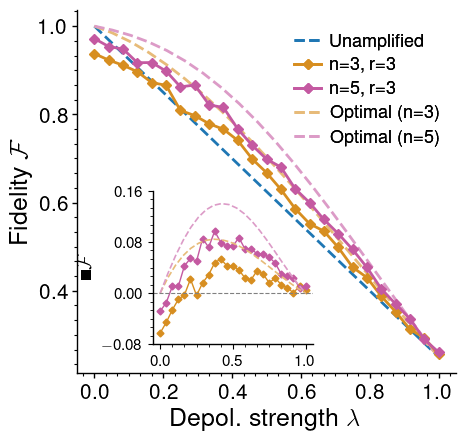

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator

# --- Style to match your other figure ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH = 72
FIGSIZE = (345 / PT_PER_INCH, 325 / PT_PER_INCH)

font_scale = 1.5
label_fs = int(12 * font_scale)
legend_fs = int(9 * font_scale)
tick_labelsize = int(10 * font_scale)
scaled_markersize = 5

# --- Parameters for nqpa0 source: must match the working script exactly ---
k = 2
shots = 1000
lambda_min = 0.0
lambda_max = 1.0
lambda_steps = 20
nrandom = 500
gatenoise = 0.0
aer = 'false'
fake = 'false'

custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

# --- IBM data paths ---
ibm_k2_n5_path = '../shared_data/results_ibm/results_ibm_k2_n5.csv'
ibm_k2_n3_path = '../shared_data/results_ibm/results_ibm_k2_n3.csv'

# --- Folder structure for nqpa0 ---
task_type = 'three_circuits_ibm_global_sampler'
simulation_subfolder = 'simulation_outputs'
simulation_folder = f'{task_type}/{simulation_subfolder}'
filesuffix = f'k{k}_shots{shots}_lambda{lambda_min}-{lambda_max}_s{lambda_steps}_r{nrandom}_g{gatenoise}_aer{aer}_fake{fake}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'
nqpa0_csv = os.path.join(results_folder, 'nqpa0', 'combined_lambda.csv')

# --- Load IBM data ---
ibm_k2_n5 = pd.read_csv(ibm_k2_n5_path)
ibm_k2_n3 = pd.read_csv(ibm_k2_n3_path)

ibm_k2_n5['lambda'] = pd.to_numeric(ibm_k2_n5['lambda'], errors='coerce')
ibm_k2_n5['fidelity'] = pd.to_numeric(ibm_k2_n5['fidelity'], errors='coerce')
ibm_k2_n3['lambda'] = pd.to_numeric(ibm_k2_n3['lambda'], errors='coerce')
ibm_k2_n3['fidelity'] = pd.to_numeric(ibm_k2_n3['fidelity'], errors='coerce')

ibm_k2_n5 = ibm_k2_n5.dropna(subset=['lambda', 'fidelity']).sort_values('lambda')
ibm_k2_n3 = ibm_k2_n3.dropna(subset=['lambda', 'fidelity']).sort_values('lambda')

# --- Load QPA 0 exactly from the same source as your working script ---
sim_lambda = None
sim_fid = None

if os.path.exists(nqpa0_csv):
    sim_df = pd.read_csv(nqpa0_csv).sort_values('lambda')
    sim_df['lambda'] = pd.to_numeric(sim_df['lambda'], errors='coerce')
    sim_df['QPA_0'] = pd.to_numeric(sim_df['QPA_0'], errors='coerce')
    sim_df = sim_df.dropna(subset=['lambda', 'QPA_0'])

    sim_lambda = sim_df['lambda'].to_numpy(dtype=float)
    sim_fid = sim_df['QPA_0'].to_numpy(dtype=float)
    print("Loaded nqpa0 from:", nqpa0_csv)
else:
    print("Warning: nqpa0 CSV not found at:", nqpa0_csv)

# --- Theory x-grid ---
if sim_lambda is not None:
    lambda_theory = np.asarray(sim_lambda, dtype=float)
else:
    lambda_theory = np.linspace(lambda_min, lambda_max, lambda_steps)

# n = 3 theory
theory_n3 = (1 / 8.0) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory)

# n = 5 theory
theory_n5 = (1 / 640.0) * (
    640
    - 96 * lambda_theory
    - 224 * lambda_theory**2
    - 700 * lambda_theory**3
    + 693 * lambda_theory**4
    - 153 * lambda_theory**5
)

base_yellow = np.array(mpl.colors.to_rgb("#d78e20"))
light_yellow = base_yellow * 0.6 + np.ones(3) * 0.4
base_purple = np.array(mpl.colors.to_rgb("#c459a1"))
light_purple = base_purple * 0.6 + np.ones(3) * 0.4

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# QPA 0 (Unamplified)
if sim_lambda is not None and sim_fid is not None:
    h_unamp, = ax.plot(
        sim_lambda, sim_fid,
        linestyle='--', linewidth=2,
        color=custom_colors[0], label="Unamplified"
    )
else:
    h_unamp = None

# n = 3 theory
h_opt3, = ax.plot(
    lambda_theory, theory_n3,
    linestyle='--', linewidth=2, color=light_yellow, label="Optimal (n=3)"
)

# n = 5 theory
h_opt5, = ax.plot(
    lambda_theory, theory_n5,
    linestyle='--', linewidth=2, color=light_purple, label="Optimal (n=5)"
)

# IBM n = 3
h_n3, = ax.plot(
    ibm_k2_n3['lambda'].to_numpy(dtype=float),
    ibm_k2_n3['fidelity'].to_numpy(dtype=float),
    marker='D', linewidth=2, color=custom_colors[1],
    markersize=scaled_markersize, label="n=3"
)

# IBM n = 5
h_n5, = ax.plot(
    ibm_k2_n5['lambda'].to_numpy(dtype=float),
    ibm_k2_n5['fidelity'].to_numpy(dtype=float),
    marker='D', linewidth=2, color=custom_colors[2],
    markersize=scaled_markersize, label="n=5"
)

# --- Axes styling ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)

ax.set_xlabel(r"Depol. strength $\lambda$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)

# --- Custom legend order ---
legend_handles = []
legend_labels = []
if h_unamp is not None:
    legend_handles.append(h_unamp)
    legend_labels.append("Unamplified")
legend_handles.extend([h_n3, h_n5, h_opt3, h_opt5])
legend_labels.extend(["n=3, r=3", "n=5, r=3", "Optimal (n=3)", "Optimal (n=5)"])

leg = ax.legend(
    legend_handles, legend_labels,
    loc="upper right", fontsize=legend_fs, frameon=False,
    borderaxespad=0.5, handlelength=1.5, handletextpad=0.5,
    labelspacing=0.4, borderpad=0.4, columnspacing=1.0,
    ncol=1, fancybox=False, edgecolor="black", bbox_to_anchor=(1.0, 0.98)
)
ax.add_artist(leg)

# --- ΔF Inset (IBM fidelity − unamplified) ---
inset_fs = int(label_fs * 0.78)
inset_tick_fs = int(tick_labelsize * 0.78)
axins = ax.inset_axes([0.2, 0.08, 0.4224, 0.4224])
axins.patch.set_alpha(0)

if sim_lambda is not None and sim_fid is not None:
    lam_n3 = ibm_k2_n3['lambda'].to_numpy(dtype=float)
    fid_n3 = ibm_k2_n3['fidelity'].to_numpy(dtype=float)
    delta_n3 = fid_n3 - np.interp(lam_n3, sim_lambda, sim_fid)

    lam_n5 = ibm_k2_n5['lambda'].to_numpy(dtype=float)
    fid_n5 = ibm_k2_n5['fidelity'].to_numpy(dtype=float)
    delta_n5 = fid_n5 - np.interp(lam_n5, sim_lambda, sim_fid)

    unamp_at_theory = np.interp(lambda_theory, sim_lambda, sim_fid)

    axins.plot(lam_n3, delta_n3, marker='D', markersize=scaled_markersize * 0.7,
               linewidth=1, color=custom_colors[1])
    axins.plot(lam_n5, delta_n5, marker='D', markersize=scaled_markersize * 0.7,
               linewidth=1, color=custom_colors[2])
    axins.plot(lambda_theory, theory_n3 - unamp_at_theory, '--', linewidth=1.2, color=light_yellow)
    axins.plot(lambda_theory, theory_n5 - unamp_at_theory, '--', linewidth=1.2, color=light_purple)

axins.axhline(0, color='gray', linestyle='--', linewidth=0.8)
axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)
axins.spines["left"].set_linewidth(1)
axins.spines["bottom"].set_linewidth(1)
axins.xaxis.set_ticks_position("bottom")
axins.yaxis.set_ticks_position("left")
axins.xaxis.set_minor_locator(AutoMinorLocator(6))
axins.yaxis.set_minor_locator(AutoMinorLocator(6))
axins.tick_params(labelsize=inset_tick_fs, which='both', direction='out')
axins.set_yticks([-0.08, 0, 0.08, 0.16])
axins.set_xticks([0, 0.5, 1])
axins.set_ylabel(r"$\Delta\mathcal{F}$", fontsize=inset_fs)

# --- Save as SVG ---
svg_path = os.path.join(results_folder, 'ibm_experiment_panel.svg')
fig.tight_layout()
fig.savefig(svg_path, format='svg')
print('SVG saved to:', svg_path)
plt.show()